# 🛒 Lab: EDA Univariado — Amazon UK Products

**Objetivo:** Analizar la dinámica de los listados de productos en Amazon UK para obtener insights útiles para la toma de decisiones empresariales.

**Dataset:** Amazon UK Products — 2,443,651 filas × 9 columnas  
**Columnas:** `uid`, `asin`, `title`, `stars`, `reviews`, `price`, `isBestSeller`, `boughtInLastMonth`, `category`

## 0. Setup e importaciones

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Ajusta esta ruta a donde tengas el archivo CSV
df = pd.read_csv(r'C:\Users\MEL\Downloads\DATA\semana 5\amz_uk_price_prediction_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Shape: (2443651, 9)
Columnas: ['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
# Tipos de datos y valores nulos
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

Valores nulos:
uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64


**📊 Resultado:** El dataset tiene 2,443,651 productos y **no tiene valores nulos**. Sin embargo, la columna `stars` contiene 1,225,641 ceros (50.1%) que representan productos sin valoración todavía — los trataremos al analizarla.

---
## 📦 Parte 1: Comprensión de las Categorías de Productos
**Pregunta de negocio:** ¿Cuáles son las categorías más populares y cómo se comparan en frecuencia?

### 1.1 Tabla de frecuencias

In [20]:
# Tabla de frecuencias completa
print(f'Total de categorías únicas: {df["category"].nunique()}')
print('\nTop 10 categorías:')
print(df['category'].value_counts().head(10))

Total de categorías únicas: 296

Top 10 categorías:
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64


**📊 Resultado real — Top 5 categorías:**

| Categoría | Frecuencia | % |
|-----------|-----------|---|
| Sports & Outdoors | 836,265 | 34.2% |
| Beauty | 19,312 | 0.79% |
| Handmade Clothing, Shoes & Accessories | 19,229 | 0.79% |
| Bath & Body | 19,092 | 0.78% |
| Birthday Gifts | 18,978 | 0.78% |

➡️ **Sports & Outdoors domina masivamente** con el 34.2% de todos los productos — más de 17 veces la segunda categoría.

### 1.2 Gráfico de barras — Top 15 categorías

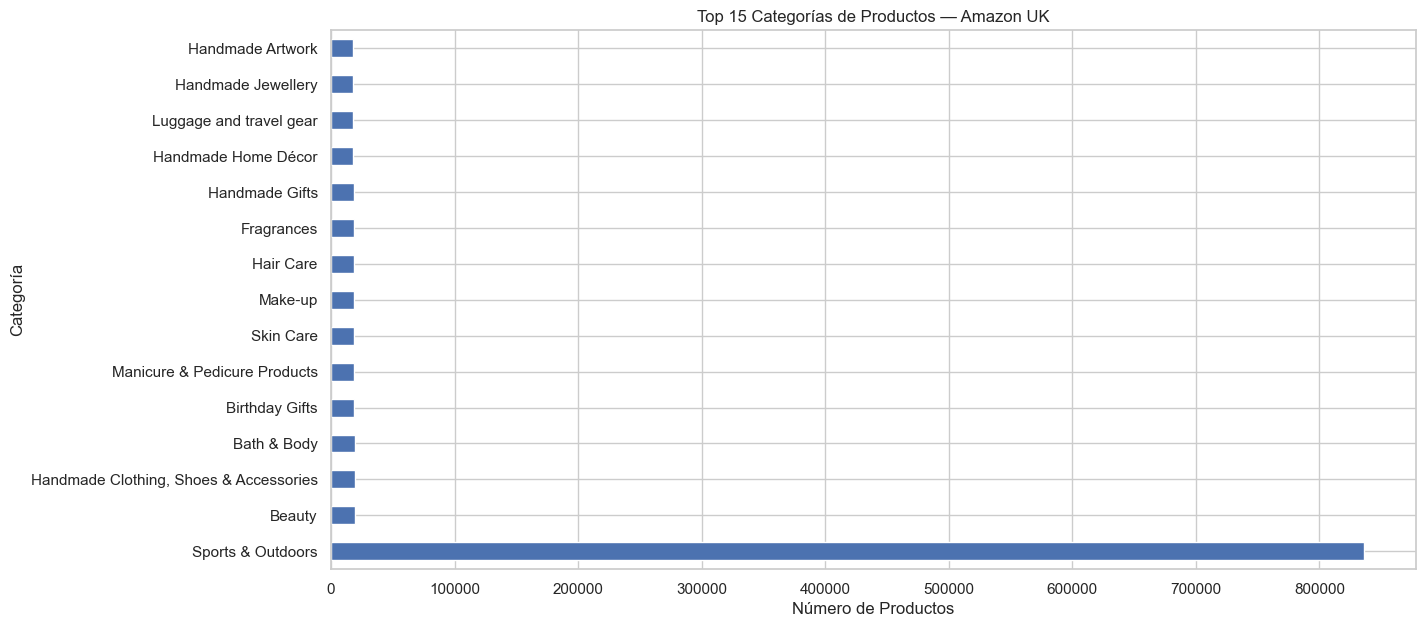

In [21]:
top15 = df['category'].value_counts().head(15)

top15.plot(kind='barh', figsize=(14, 7))
plt.title('Top 15 Categorías de Productos — Amazon UK')
plt.xlabel('Número de Productos')
plt.ylabel('Categoría')
plt.show()

### 1.3 Gráfico circular — Proporciones (Top 10 + Otros)

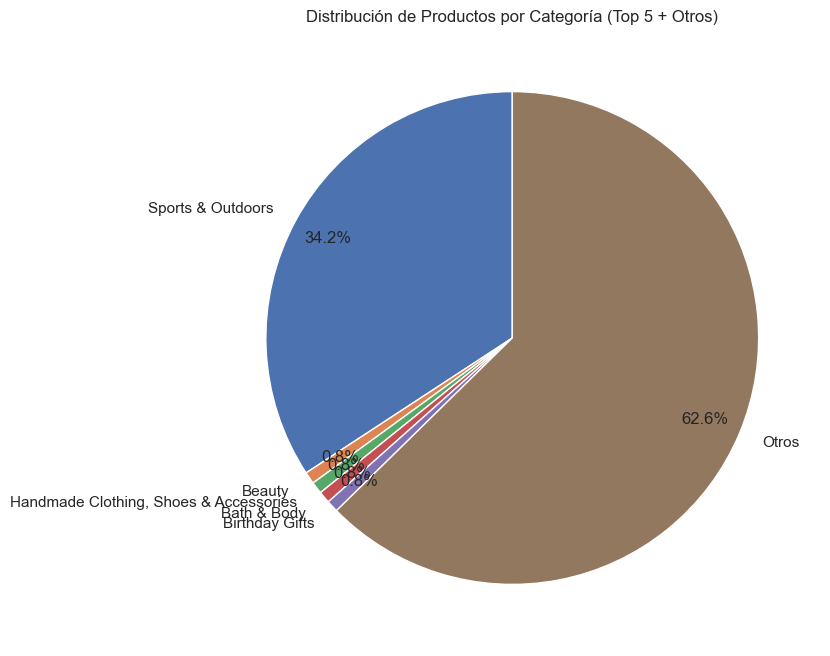

In [25]:
top5 = df['category'].value_counts().head(5)
otros = df['category'].value_counts().iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Otros': otros})])

pie_data.plot(kind='pie', figsize=(10, 8), autopct='%1.1f%%', 
              startangle=90, pctdistance=0.85)
plt.title('Distribución de Productos por Categoría (Top 5 + Otros)')
plt.ylabel('')
plt.show()

**💡 Insight de negocio:** Sports & Outdoors **predomina claramente** en el catálogo. Esto puede indicar que Amazon UK tiene una oferta muy desarrollada en ese segmento, o que los vendedores tienden a clasificar muchos productos en esa categoría. Las demás categorías tienen participaciones muy similares entre sí (< 1% cada una).

---
## 💰 Parte 2: Análisis de Precios
**Pregunta de negocio:** ¿Cómo se fijan los precios y qué rangos son más comunes?

### 2.1 Medidas de centralidad

In [26]:
print('=== MEDIDAS DE CENTRALIDAD — PRECIO ===')
print(f'Media:   £{df["price"].mean():.2f}')
print(f'Mediana: £{df["price"].median():.2f}')
print(f'Moda:    £{df["price"].mode()[0]:.2f}')

=== MEDIDAS DE CENTRALIDAD — PRECIO ===
Media:   £89.24
Mediana: £19.09
Moda:    £9.99


**📊 Resultado real:**
- Media: **£89.24** | Mediana: **£19.09** | Moda: **£9.99**

➡️ La gran diferencia entre media (£89) y mediana (£19) revela un **sesgo positivo fuerte** — unos pocos productos muy caros elevan la media artificialmente. El precio más frecuente es £9.99, reflejando la estrategia clásica de precios psicológicos.

### 2.2 Medidas de dispersión

In [27]:
print('=== MEDIDAS DE DISPERSIÓN — PRECIO ===')
print(f'Varianza:        {df["price"].var():,.2f}')
print(f'Desv. estándar:  £{df["price"].std():.2f}')
print(f'Rango:           £{df["price"].max() - df["price"].min():,.2f}')
print(f'IQR (Q1 - Q3):   £{df["price"].quantile(0.75) - df["price"].quantile(0.25):.2f}')

=== MEDIDAS DE DISPERSIÓN — PRECIO ===
Varianza:        119,445.49
Desv. estándar:  £345.61
Rango:           £100,000.00
IQR (Q1 - Q3):   £36.00


**📊 Resultado real:**
- Desv. estándar: **£345.61** | Rango: **£100,000** | IQR: **£36** (£9.99 — £45.99)

➡️ La desviación estándar de £345 es **mayor que la media (£89)**, lo que indica una dispersión extrema. Sin embargo, el 50% central de los productos se concentra en el rango £9.99–£45.99, mostrando que la gran mayoría son productos de precio moderado. Los outliers (productos de miles de libras) distorsionan fuertemente las métricas globales.

### 2.3 Histograma de precios

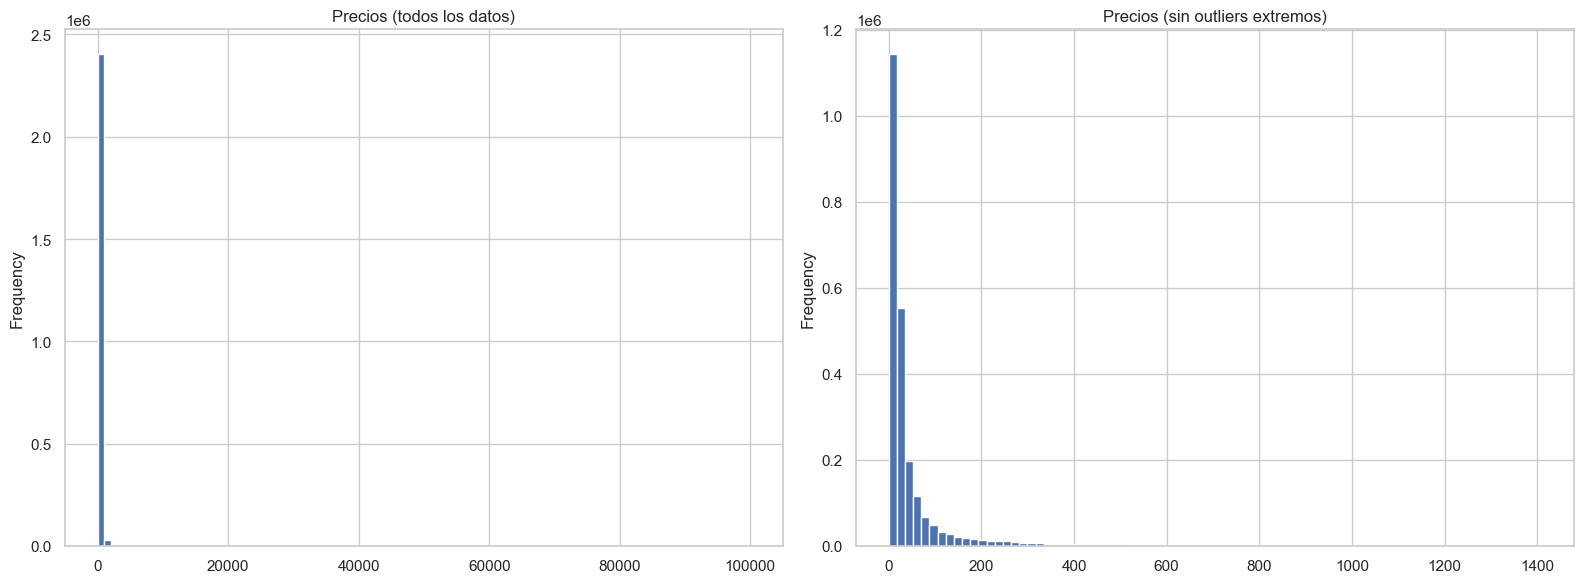

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Todos los datos
df['price'].plot(kind='hist', bins=100, ax=axes[0], title='Precios (todos los datos)')

# Sin outliers extremos
price_trim = df[df['price'] <= df['price'].quantile(0.99)]['price']
price_trim.plot(kind='hist', bins=80, ax=axes[1], title='Precios (sin outliers extremos)')

plt.tight_layout()
plt.show()

**💡 ¿Por qué el histograma izquierdo es difícil de interpretar?**

Porque los outliers extremos (productos hasta £100,000) comprimen todos los datos en la primera barra. La solución es eliminar o recortar los extremos — como se ve en el histograma derecho, que revela la distribución real: **la mayoría de productos se concentran entre £0 y £100**, con un pico claro alrededor de £10-20.

### 2.4 Boxplot de precios

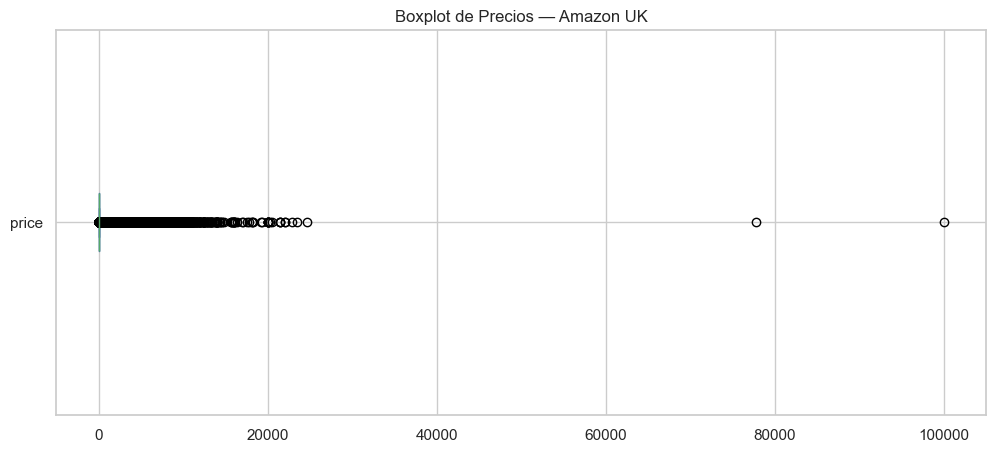

In [31]:
df['price'].plot(kind='box', vert=False, figsize=(12, 5))
plt.title('Boxplot de Precios — Amazon UK')
plt.show()

**💡 Insight:** El boxplot confirma que **existen productos con precios significativamente más altos**. La caja (50% central) es muy estrecha (£9.99–£45.99) pero la nube de puntos se extiende hasta £100,000. Estos outliers representan productos especializados o de lujo.

---
##  Parte 3: Análisis de Valoraciones (Ratings)
**Pregunta de negocio:** ¿Cómo valoran los clientes los productos y hay patrones en las valoraciones?

**Nota importante:** La columna `stars` contiene 1,225,641 valores `0.0` (50.1% del dataset) que representan productos **sin ninguna valoración** todavía. Los excluimos del análisis para obtener métricas reales de los productos valorados.

In [34]:
# Filtramos productos sin valoración
rating = df[df['stars'] > 0]['stars']

print(f'Sin valoración: {(df["stars"] == 0).sum():,}')
print(f'Con valoración: {len(rating):,}')

Sin valoración: 1,225,641
Con valoración: 1,218,010


### 3.1 Medidas de centralidad

In [19]:
mean_r   = rating.mean()
median_r = rating.median()
mode_r   = rating.mode()[0]

print('=== MEDIDAS DE CENTRALIDAD — RATING ===')
print(f'Media:   {mean_r:.4f} ')
print(f'Mediana: {median_r:.4f} ')
print(f'Moda:    {mode_r:.4f} ')

=== MEDIDAS DE CENTRALIDAD — RATING ===
Media:   4.3192 
Mediana: 4.4000 
Moda:    4.5000 


**📊 Resultado real:**
- Media: **4.32 ⭐** | Mediana: **4.40 ⭐** | Moda: **4.50 ⭐**

➡️ Los clientes tienden a dar valoraciones **altas** en Amazon UK. La moda de 4.5 y la mediana de 4.4 indican que más de la mitad de los productos valorados superan las 4 estrellas. Esto es consistente con el fenómeno conocido como *"review bias"* — los compradores satisfechos dejan más reseñas.

### 3.2 Medidas de dispersión

In [35]:
print('=== MEDIDAS DE DISPERSIÓN — RATING ===')
print(f'Varianza:       {rating.var():.4f}')
print(f'Desv. estándar: {rating.std():.4f}')
print(f'IQR:            {rating.quantile(0.75) - rating.quantile(0.25):.4f}')

=== MEDIDAS DE DISPERSIÓN — RATING ===
Varianza:       0.3083
Desv. estándar: 0.5553
IQR:            0.5000


**📊 Resultado real:**
- Desv. estándar: **0.56** | IQR: **0.5** (4.0 — 4.5)

➡️ Las valoraciones son **muy consistentes** — la desviación estándar de solo 0.56 sobre una escala de 1-5 indica poca variación. El 50% central de los productos tiene entre 4.0 y 4.5 estrellas.

### 3.3 Forma de la distribución — Asimetría y curtosis

In [36]:
print(f'Asimetría: {rating.skew():.4f}')
print(f'Curtosis:  {rating.kurt():.4f}')

Asimetría: -2.3796
Curtosis:  9.7819


**📊 Resultado real:**
- Asimetría: **-2.38** (fuerte sesgo negativo)
- Curtosis: **9.78** (muy leptocúrtica)

➡️ Los ratings **NO siguen una distribución normal**. Están fuertemente concentrados en valores altos (4-5 estrellas) con muy pocos productos mal valorados.

### 3.4 Histograma de ratings

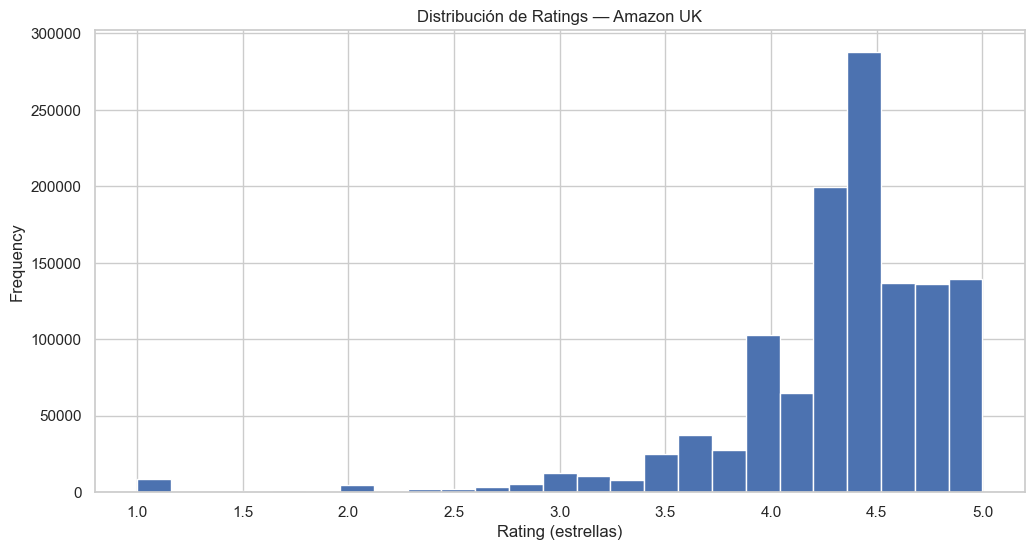

<Figure size 1200x600 with 0 Axes>

In [37]:
rating.plot(kind='hist', bins=25, figsize=(12, 6), title='Distribución de Ratings — Amazon UK')
plt.xlabel('Rating (estrellas)')
plt.show()

plt.tight_layout()
plt.show()

**💡 Insight:** La calificación **4.5 estrellas es la más común** (moda). El histograma muestra una concentración clara en el rango 4.0–5.0. Prácticamente ningún producto tiene entre 1 y 3 estrellas en el catálogo activo — los productos con malas valoraciones probablemente desaparecen del marketplace.

---
##  Informe de Negocio — Resumen Ejecutivo

### Parte 1 — Categorías
- Amazon UK tiene **296 categorías** con un total de 2.4M productos.
- **Sports & Outdoors domina con el 34.2%** del catálogo — una concentración inusual que sugiere una oportunidad de mercado o un sesgo en la categorización.
- Las demás categorías tienen participaciones muy similares (< 1%), lo que indica un mercado diversificado excepto por este segmento.
- **Recomendación:** Investigar si Sports & Outdoors es una categoría paraguas que absorbe productos de otras, o si realmente es la más competida.

### Parte 2 — Precios
- El precio típico (mediana) es **£19.09** y el más frecuente es **£9.99** — el mercado es predominantemente de productos asequibles.
- La media de £89.24 está distorsionada por outliers extremos (hasta £100,000).
- El **50% de los productos** se venden entre £9.99 y £45.99.
- **Recomendación:** Para nuevos vendedores, posicionarse en el rango £10-£50 es la estrategia más competitiva. Los precios psicológicos (£9.99, £19.99) son muy frecuentes.

### Parte 3 — Ratings
- Los productos valorados tienen de media **4.32 ** — un estándar muy alto.
- La distribución es **fuertemente asimétrica negativa** (skewness = -2.38): los clientes tienden a dejar reseñas positivas.
- La curtosis elevada (9.78) indica que las valoraciones se concentran en 4.5 estrellas.
- **Recomendación:** En Amazon UK la barra de calidad es alta. Un producto con menos de 4.0 estrellas estará en desventaja competitiva clara.